### Part 0: Imports & Setup

In [148]:
import torch
import torch.nn as nn
import torch.optim as optim

from scipy.io import arff
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Fixes randomness for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device detection
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"PyTorch version : {torch.__version__}")
print(f"Running on      : {device.upper()}")

PyTorch version : 2.11.0+cu130
Running on      : CPU


### Part 1: Data Loading, Preprocessing & Overview

In [150]:
data, meta = arff.loadarff('adult.arff')
df = pd.DataFrame(data)

# Identify and decode byte string columns due to ARFF loading
for col in df.columns:
    # Check if the column data type is 'object' and contains byte strings
    if df[col].dtype == 'object':
        try:
            df[col] = df[col].str.decode('utf-8')
        except AttributeError:
            # Handle cases where some 'object' columns might not be byte strings
            pass

# Replace '?' character with NaN and drop rows with missing values
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)

### Part 2: Exploratory Data Analysis (EDA)

In [151]:
# Overview the dataset before encoding
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 45222 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             45222 non-null  float64
 1   workclass       45222 non-null  object 
 2   fnlwgt          45222 non-null  float64
 3   education       45222 non-null  object 
 4   education-num   45222 non-null  float64
 5   marital-status  45222 non-null  object 
 6   occupation      45222 non-null  object 
 7   relationship    45222 non-null  object 
 8   race            45222 non-null  object 
 9   sex             45222 non-null  object 
 10  capital-gain    45222 non-null  float64
 11  capital-loss    45222 non-null  float64
 12  hours-per-week  45222 non-null  float64
 13  native-country  45222 non-null  object 
 14  class           45222 non-null  object 
dtypes: float64(6), object(9)
memory usage: 5.5+ MB


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25.0,Private,226802.0,11th,7.0,Never-married,Machine-op-inspct,Own-child,Black,Male,0.0,0.0,40.0,United-States,<=50K
1,38.0,Private,89814.0,HS-grad,9.0,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,50.0,United-States,<=50K
2,28.0,Local-gov,336951.0,Assoc-acdm,12.0,Married-civ-spouse,Protective-serv,Husband,White,Male,0.0,0.0,40.0,United-States,>50K
3,44.0,Private,160323.0,Some-college,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688.0,0.0,40.0,United-States,>50K
5,34.0,Private,198693.0,10th,6.0,Never-married,Other-service,Not-in-family,White,Male,0.0,0.0,30.0,United-States,<=50K


In [152]:
# Encode categorical features using LabelEncoder before scaling

# Map categories to 0 and 1
df['workclass'] = LabelEncoder().fit_transform(df['workclass'])
df['education'] = LabelEncoder().fit_transform(df['education'])
df['occupation'] = LabelEncoder().fit_transform(df['occupation'])
df['relationship'] = LabelEncoder().fit_transform(df['relationship'])
df['race'] = LabelEncoder().fit_transform(df['race'])
df['sex'] = LabelEncoder().fit_transform(df['sex'])
df['native-country'] = LabelEncoder().fit_transform(df['native-country'])
df['class'] = LabelEncoder().fit_transform(df['class'])
df['marital-status'] = LabelEncoder().fit_transform(df['marital-status'])

# Overview the dataset after encoding
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 45222 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             45222 non-null  float64
 1   workclass       45222 non-null  int64  
 2   fnlwgt          45222 non-null  float64
 3   education       45222 non-null  int64  
 4   education-num   45222 non-null  float64
 5   marital-status  45222 non-null  int64  
 6   occupation      45222 non-null  int64  
 7   relationship    45222 non-null  int64  
 8   race            45222 non-null  int64  
 9   sex             45222 non-null  int64  
 10  capital-gain    45222 non-null  float64
 11  capital-loss    45222 non-null  float64
 12  hours-per-week  45222 non-null  float64
 13  native-country  45222 non-null  int64  
 14  class           45222 non-null  int64  
dtypes: float64(6), int64(9)
memory usage: 5.5 MB


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25.0,2,226802.0,1,7.0,4,6,3,2,1,0.0,0.0,40.0,38,0
1,38.0,2,89814.0,11,9.0,2,4,0,4,1,0.0,0.0,50.0,38,0
2,28.0,1,336951.0,7,12.0,2,10,0,4,1,0.0,0.0,40.0,38,1
3,44.0,2,160323.0,15,10.0,2,6,0,2,1,7688.0,0.0,40.0,38,1
5,34.0,2,198693.0,0,6.0,4,7,1,4,1,0.0,0.0,30.0,38,0


In [153]:
X, y = df.drop('class', axis=1), df['class']
CLASS_NAMES = y.unique()

In [154]:
# ── Basic facts ───────────────────────────────────────────────────────────────
print(f"X shape : {X.shape}  →  {X.shape[0]} samples, {X.shape[1]} features")
print(f"Classes : {list(CLASS_NAMES)}")
print()

# ── Class balance ─────────────────────────────────────────────────────────────
# This dataset is imbalanced: 75% of samples belong to class '<=50K', and 25% to '>50K'.
print("Class Distribution:")
class_counts = y.value_counts()
for class_name, count in class_counts.items():
    print(f"  Class '{class_name}' : {count} samples")
print()

# ── Feature ranges ────────────────────────────────────────────────────────────
# The features have varying ranges. For example, 'age' ranges from 17 to 90, while 'hours-per-week' ranges from 1 to 99. This suggests that feature scaling may be necessary before training a model.
print("Feature Ranges:")
for col in X.columns:
    print(f"  {col:<20} : {X[col].min():>5} to {X[col].max():>5}")
print()

X shape : (45222, 14)  →  45222 samples, 14 features
Classes : [0, 1]

Class Distribution:
  Class '0' : 34014 samples
  Class '1' : 11208 samples

Feature Ranges:
  age                  :  17.0 to  90.0
  workclass            :     0 to     6
  fnlwgt               : 13492.0 to 1490400.0
  education            :     0 to    15
  education-num        :   1.0 to  16.0
  marital-status       :     0 to     6
  occupation           :     0 to    13
  relationship         :     0 to     5
  race                 :     0 to     4
  sex                  :     0 to     1
  capital-gain         :   0.0 to 99999.0
  capital-loss         :   0.0 to 4356.0
  hours-per-week       :   1.0 to  99.0
  native-country       :     0 to    40




Feature Importance (Based on numerical features):
relationship      0.116578
marital-status    0.113047
capital-gain      0.087178
age               0.066524
education         0.064091
education-num     0.063776
occupation        0.061411
hours-per-week    0.040099
fnlwgt            0.039291
capital-loss      0.036706
sex               0.029900
workclass         0.016886
race              0.011008
native-country    0.007671
dtype: float64


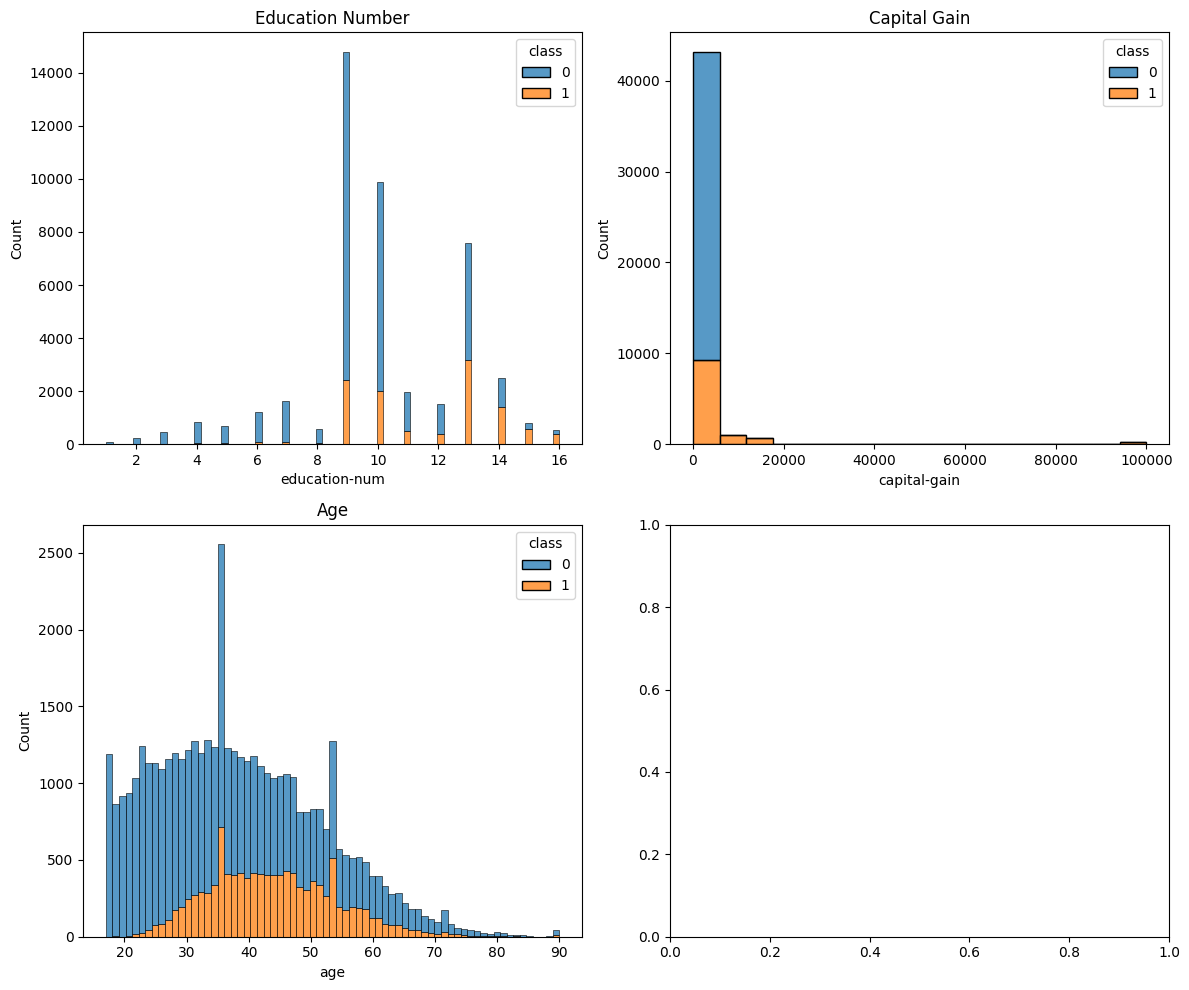

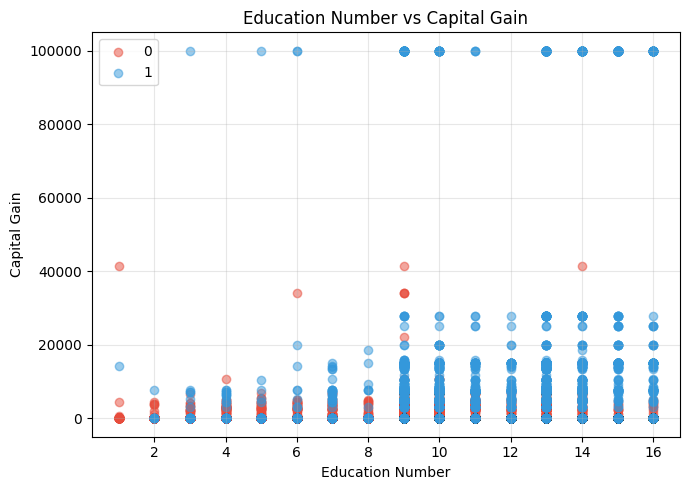

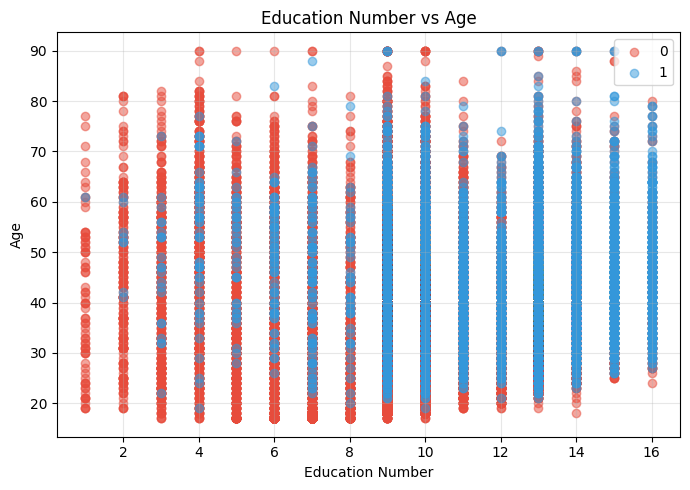

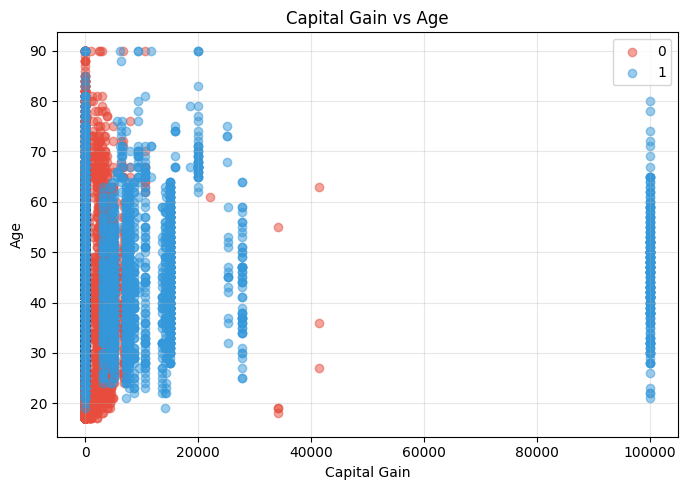

In [155]:
# Returns a score for each feature (higher = more discriminative)
feature_scores = mutual_info_classif(X.select_dtypes(include=[np.number]), y)
feature_importance = pd.Series(feature_scores, index=X.select_dtypes(include=[np.number]).columns).sort_values(ascending=False)
print("\nFeature Importance (Based on numerical features):")
print(feature_importance)

# Most discriminative features: 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week'.
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(data=df, x='education-num', hue='class', multiple='stack', ax=axes[0,0])
sns.histplot(data=df, x='capital-gain', hue='class', multiple='stack', ax=axes[0,1])
sns.histplot(data=df, x='age', hue='class', multiple='stack', ax=axes[1,0])
axes[0,0].set_title('Education Number')
axes[0,1].set_title('Capital Gain')
axes[1,0].set_title('Age')
plt.tight_layout()
plt.show()

# Quick scatter - features (education-num, capital gain) within classes
COLORS = ['#e74c3c', '#3498db']
fig, ax = plt.subplots(figsize=(7, 5))
for i, name in enumerate(CLASS_NAMES):
    mask = (y == name)
    ax.scatter(X.loc[mask, 'education-num'], X.loc[mask, 'capital-gain'], label=name, alpha=0.5, color=COLORS[i])
ax.set_xlabel('Education Number')
ax.set_ylabel('Capital Gain')
ax.set_title('Education Number vs Capital Gain')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()   

# Quick scatter - features (education-num, age) within classes
COLORS = ['#e74c3c', '#3498db']
fig, ax = plt.subplots(figsize=(7, 5))
for i, name in enumerate(CLASS_NAMES):
    mask = (y == name)
    ax.scatter(X.loc[mask, 'education-num'], X.loc[mask, 'age'], label=name, alpha=0.5, color=COLORS[i])
ax.set_xlabel('Education Number')
ax.set_ylabel('Age')
ax.set_title('Education Number vs Age')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()  

# Quick scatter - features (capital-gain, age) within classes
COLORS = ['#e74c3c', '#3498db']
fig, ax = plt.subplots(figsize=(7, 5))
for i, name in enumerate(CLASS_NAMES):
    mask = (y == name)
    ax.scatter(X.loc[mask, 'capital-gain'], X.loc[mask, 'age'], label=name, alpha=0.5, color=COLORS[i])
ax.set_xlabel('Capital Gain')
ax.set_ylabel('Age')
ax.set_title('Capital Gain vs Age')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()  

### Part 3: Prepare Data for Training

In [156]:
# Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"Train : {X_train.shape}  ({len(X_train)} samples)")
print(f"Test  : {X_test.shape}   ({len(X_test)} samples)")
print()

Train : (36177, 14)  (36177 samples)
Test  : (9045, 14)   (9045 samples)



In [157]:
# Scale data for training
scaler  = StandardScaler()

X_train = scaler.fit_transform(X_train)  # Learns μ and σ from training data
X_test  = scaler.transform(X_test)       # Applies training μ/σ to test — no leakage!

print(f"After scaling — Train mean : {X_train.mean(axis=0).round(2)}  (should be ≈ 0)")
print(f"After scaling — Train std  : {X_train.std(axis=0).round(2)}   (should be ≈ 1)")
print()

After scaling — Train mean : [-0.  0.  0. -0. -0.  0. -0.  0. -0. -0.  0. -0. -0. -0.]  (should be ≈ 0)
After scaling — Train std  : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]   (should be ≈ 1)

